In [1]:
from qiskit.circuit.random import random_circuit
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit_aer import AerSimulator
from qiskit import transpile

from typing import List

In [2]:
import warnings
# Suppress RuntimeWarnings related to division by zero and invalid values when transpiling the circuits
warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in det")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in det")

In [3]:
# Import required libraries for dynamical decoupling implementation
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis as alap_qiskit
from qiskit.transpiler.passes.scheduling import PadDynamicalDecoupling as pad_dd_qiskit
from qiskit.transpiler import PassManager
from qiskit.circuit.library import XGate
from qiskit.visualization.timeline import draw, IQXStandard
import matplotlib.pyplot as plt

# Set up the noisy device simulation
# FakeWashington provides realistic noise characteristics and timing information
NOISY_DEVICE = FakeTorino()
print(f"Backend: {NOISY_DEVICE.name}")
print(f"Number of qubits: {NOISY_DEVICE.num_qubits}")


Backend: fake_torino
Number of qubits: 133


In [4]:
nqubits = 4
circ = QuantumCircuit(nqubits)

# Apply Hadamard to create superposition
circ.h(0)

# Create a chain of CNOT gates for entanglement
for i in range(0, nqubits - 1):
    circ.cx(i, i + 1)
circ.measure_all()

# nqubits = n = 9
# circ = QuantumCircuit(n+1, n)
# circ.h(range(n+1))
# for i in range(n):
#     circ.cx(i, i+1)
# circ.barrier()
# circ.measure(range(1, n+1), range(n))

circ_no_meas = circ.remove_final_measurements(inplace=False)


# Add measurements
# circ.measure_all()

# Store the original circuit for later comparison

print("Original quantum circuit created with 4 qubits")
print(f"Circuit depth: {circ.depth()}")
print(f"Number of gates: {sum(circ.count_ops().values())}")

Original quantum circuit created with 4 qubits
Circuit depth: 5
Number of gates: 9


In [5]:
TRANSPILED_QC_MEASURED = transpile(circ, NOISY_DEVICE, optimization_level=3, seed_transpiler=42)

In [6]:
from qiskit.transpiler import generate_preset_pass_manager

pm_lvl3 = generate_preset_pass_manager(optimization_level=3, seed_transpiler=42, backend=NOISY_DEVICE)
TRANSPILED_QC_PRESET_NO_MEASURE = pm_lvl3.run(circ)

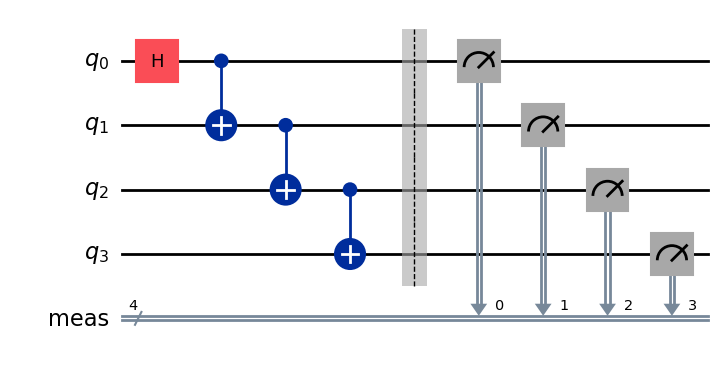

In [7]:
circ.draw(output = 'mpl', fold = -1)

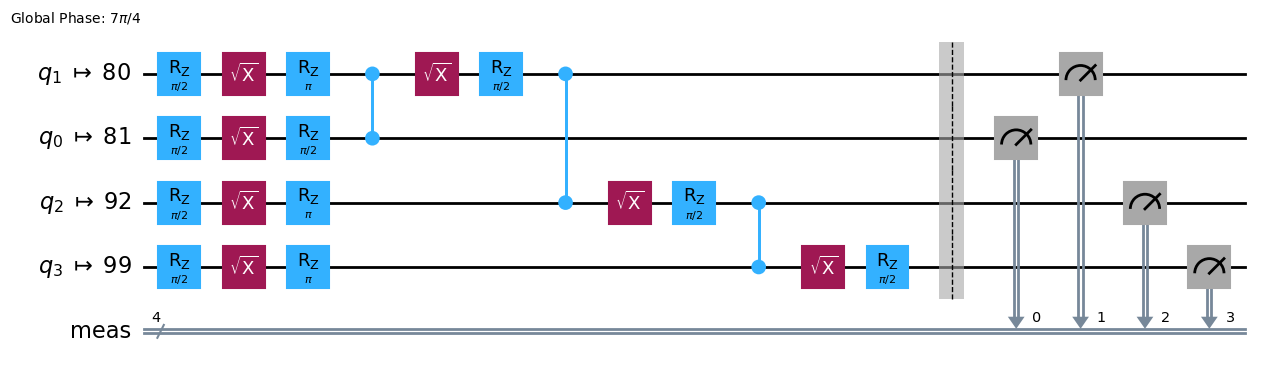

In [8]:
TRANSPILED_QC_MEASURED.draw(output = 'mpl', fold = -1, idle_wires=False)

In [9]:
from qiskit.transpiler import Target
from qiskit import QuantumCircuit

def print_qubit_error_rates_for_circuit(circ: QuantumCircuit, phys_qubits, target: Target):
    """
    Print readout error rates and two-qubit gate errors only for pairs
    that are actually used in the given circuit and are within phys_qubits.
    
    Args:
        circ (QuantumCircuit): Transpiled circuit (physical qubits).
        phys_qubits (list[int]): Physical qubit indices to consider.
        target (Target): Backend target object.
    """
    phys_qubits = set(phys_qubits)

    # Collect all two-qubit pairs from the circuit
    used_pairs = set()
    for instr, qargs, _ in circ.data:
        if len(qargs) == 2:
            pair = tuple(sorted([circ.find_bit(q).index for q in qargs]))
            if pair[0] in phys_qubits and pair[1] in phys_qubits:
                used_pairs.add(pair)

    # Print readout errors
    for q in phys_qubits:
        print(f"=== Qubit {q} ===")
        meas_props = target.get("measure", {}).get((q,), None)
        if meas_props and meas_props.error is not None:
            print(f"Readout error: {meas_props.error:.5f}")
        else:
            print("Readout error: N/A")
        print("")  # spacing

    # Print two-qubit gate errors only for used pairs
    if used_pairs:
        print("=== Two-Qubit Gate Errors (only pairs used in circuit) ===")
        for gate, qubit_dict in target.items():
            if qubit_dict is None:
                continue
            for qarg_tuple, inst_props in qubit_dict.items():
                if inst_props is None or inst_props.error is None:
                    continue
                if len(qarg_tuple) == 2:
                    pair = qarg_tuple
                    if pair in used_pairs:
                        print(f"Gate error [{gate} on {pair}]: {inst_props.error:.5f}")
    else:
        print("No two-qubit gates found in circuit.")


In [10]:
NOISY_DEVICE.target.items()

dict_items([('reset', {(0,): InstructionProperties(duration=1.708e-06, error=None), (1,): InstructionProperties(duration=1.708e-06, error=None), (2,): InstructionProperties(duration=1.692e-06, error=None), (3,): InstructionProperties(duration=1.692e-06, error=None), (4,): InstructionProperties(duration=1.728e-06, error=None), (5,): InstructionProperties(duration=1.692e-06, error=None), (6,): InstructionProperties(duration=1.708e-06, error=None), (7,): InstructionProperties(duration=1.708e-06, error=None), (8,): InstructionProperties(duration=1.784e-06, error=None), (9,): InstructionProperties(duration=1.672e-06, error=None), (10,): InstructionProperties(duration=1.752e-06, error=None), (11,): InstructionProperties(duration=1.752e-06, error=None), (12,): InstructionProperties(duration=1.72e-06, error=None), (13,): InstructionProperties(duration=1.752e-06, error=None), (14,): InstructionProperties(duration=1.752e-06, error=None), (15,): InstructionProperties(duration=1.692e-06, error=Non

In [11]:
print_qubit_error_rates_for_circuit(TRANSPILED_QC_MEASURED, [80, 81, 92, 99], NOISY_DEVICE.target)

=== Qubit 80 ===
Readout error: 0.02295

=== Qubit 81 ===
Readout error: 0.00537

=== Qubit 99 ===
Readout error: 0.00952

=== Qubit 92 ===
Readout error: 0.00903

=== Two-Qubit Gate Errors (only pairs used in circuit) ===
Gate error [cz on (80, 81)]: 0.00375
Gate error [cz on (80, 92)]: 0.00307
Gate error [cz on (92, 99)]: 0.00318


/tmp/ipykernel_10096/2133799187.py:18: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in circ.data:


---
# Applying Dynamical Decoupling


In [12]:
DD_SEQUENCE = [XGate(), XGate()]

DD_PM = PassManager(
    [
        alap_qiskit(NOISY_DEVICE.instruction_durations),
        pad_dd_qiskit(durations=NOISY_DEVICE.instruction_durations, dd_sequence=DD_SEQUENCE),
    ]
)

In [13]:
def dynamical_decoupling_preprocess(input_circuit: QuantumCircuit, dd_pass_manager = DD_PM) -> QuantumCircuit:
    """Apply dynamical decoupling to the input circuit.

    Args:
        input_circuit (QuantumCircuit): input circuit to run error mitigation on.
    """
    return dd_pass_manager.run(input_circuit)

In [14]:
dd_circ_measured = dynamical_decoupling_preprocess(TRANSPILED_QC_MEASURED)

In [ ]:
my_style = {
    'formatter.general.fig_width': 40,
    'formatter.general.fig_unit_height': 2,
}

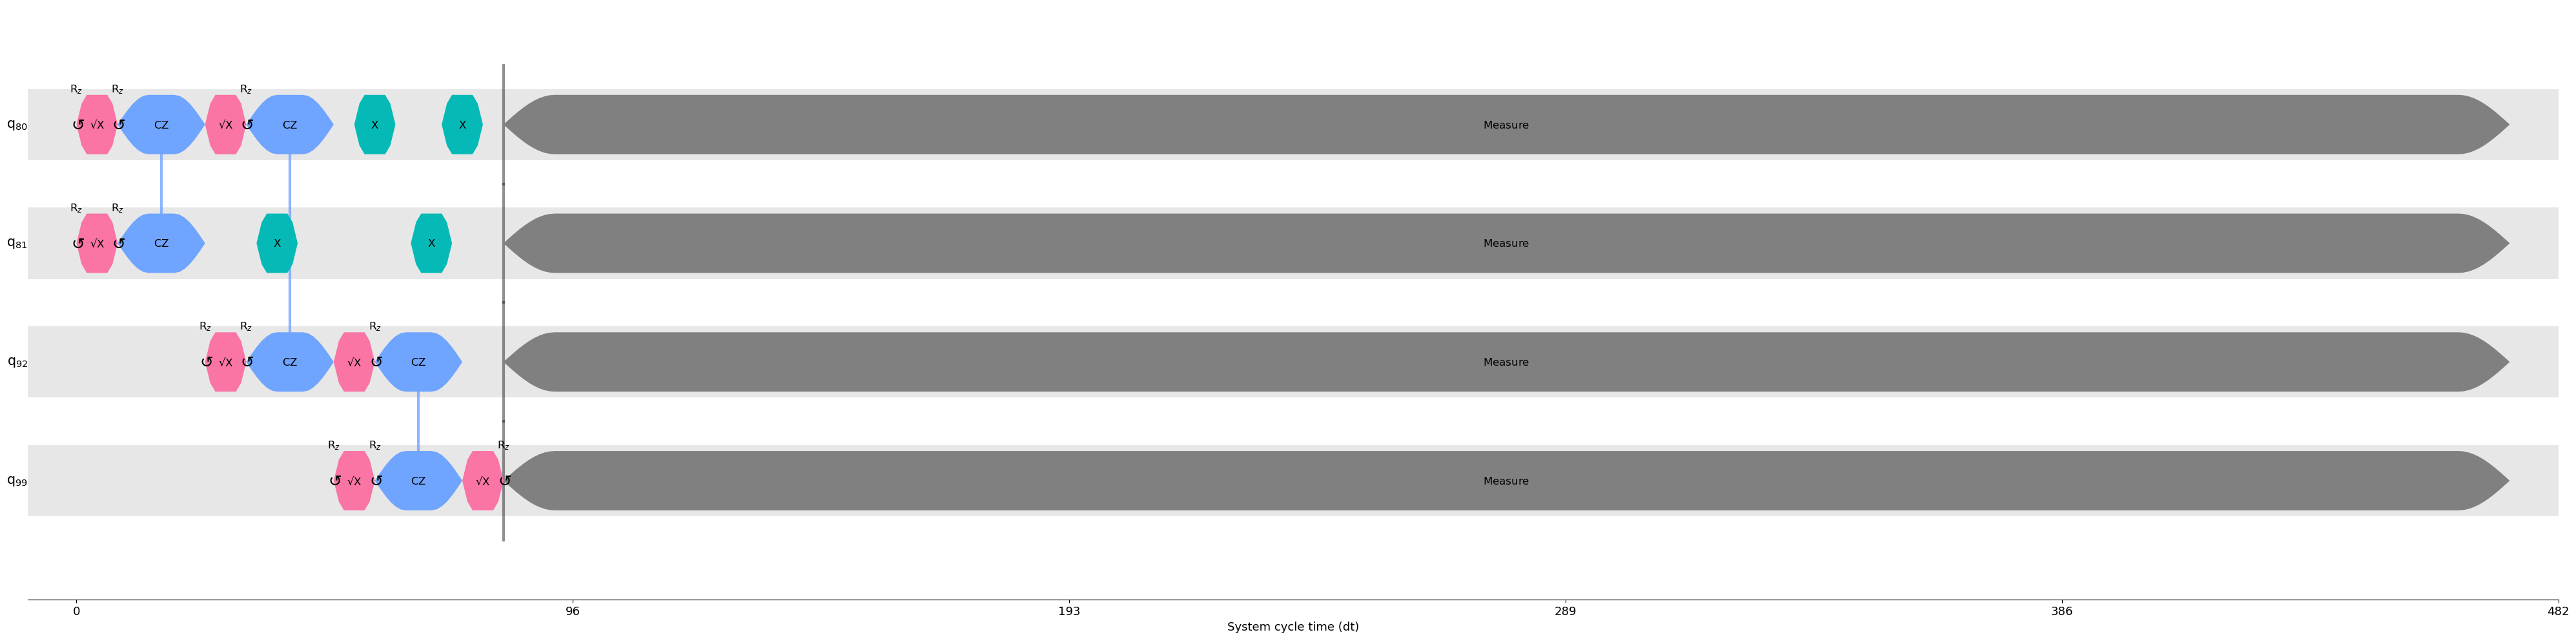

In [16]:
draw(dd_circ_measured, target=NOISY_DEVICE.target, style=IQXStandard(**my_style), show_idle=False, show_delays=False)